## Análisis de Datos Meteorológicos con una API Pública
Obtener datos del clima de una ciudad usando la API de Open-Meteo (https://open-meteo.com/) y mostrar el pronóstico para Bilbao.

* Haz una petición a la API para que devuelva el pronóstico de las temperaturas para una semana en Bilbao. Tip: el parámetro correspondiente en el query es `temperature_2m` además de la latitud y la longitud.
* Procesa la respuesta en formato JSON para obtener dos listas: una con la lista de temperaturas y otra con las fechas-horas correspondientes.
* Crea un DataFrame con esas dos columnas: `Hora` y `Temperatura`
* Elige la gráfica adecuada y visualiza el pronóstico de temperaturas.

Para crear la variable `Hora` del DataFrame puedes introducir directamente la lista que se obtiene del campo `data["hourly"]["time"]` o procesar esa lista mediante el siguiente código:

`hours = pd.date_range(start=lista_de_horas, periods=len(temps), freq="H")`

In [5]:
import requests
import pandas as pd


# Coordenadas de Kuna en Bilbao
latitude = 43.2540
longitude = -2.9230


url = f"https://api.open-meteo.com/v1/forecast?"  # Aquí vienen el resto de los parámetros

In [3]:
import requests

# Coordenadas de Bilbao
latitude = 43.2540
longitude = -2.9230

url = "https://api.open-meteo.com/v1/forecast?"

# Definimos los parámetros en un diccionario para mayor seguridad
query_params = {"latitude": latitude,"longitude": longitude,"hourly": "temperature_2m","timezone": "auto"}

try:
    # Pasamos los parámetros usando el argumento 'params'
    response = requests.get(url, params=query_params)
    
    # Esto lanzará una excepción si el código de estado no es 200
    response.raise_for_status() 
    
    data = response.json()
    print("Conexión exitosa. Temperatura actual (primera hora):", 
          data['hourly']['temperature_2m'][0], "°C")

except requests.exceptions.HTTPError as err:
    print(f"Error de la API: {err}")
    # Si hay un error 400, la API suele enviar un JSON explicando el porqué
    print("Detalle del error:", response.json().get('reason', 'No especificado'))
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")
    # 2. Procesamiento del JSON para obtener las dos listas
    # La API devuelve 'time' y 'temperature_2m' como listas de 168 elementos (24h * 7 días)
    lista_fechas = data['hourly']['time']
    lista_temperaturas = data['hourly']['temperature_2m']
    
    # Verificamos los primeros 5 elementos de cada lista
    print("Primeras 5 fechas-horas:", lista_fechas[:5])
    print("Primeras 5 temperaturas:", lista_temperaturas[:5])
    
    # Ejemplo de uso: ¿Cuántos datos tenemos en total?
    print(f"\nSe han procesado {len(lista_fechas)} registros para la próxima semana.")

else:
    print(f"Error: {response.status_code}")



Conexión exitosa. Temperatura actual (primera hora): 12.5 °C
Error: 200


In [6]:
# Extraemos las listas del JSON
lista_fechas = data['hourly']['time']
lista_temperaturas = data['hourly']['temperature_2m']

# 1. Creamos el DataFrame
df = pd.DataFrame({
    'Hora': lista_fechas,
    'Temperatura': lista_temperaturas
})

# 2. Opcional: Convertir la columna 'Hora' a formato datetime real
# Esto permite hacer cálculos temporales mucho más fáciles después
df['Hora'] = pd.to_datetime(df['Hora'])

# Mostramos las primeras filas del DataFrame
print(df.head())

# Si quieres ver estadísticas rápidas (media, max, min) de la semana:
print("\nResumen estadístico:")
print(df['Temperatura'].describe())

                 Hora  Temperatura
0 2026-03-23 00:00:00         12.5
1 2026-03-23 01:00:00         12.3
2 2026-03-23 02:00:00         12.1
3 2026-03-23 03:00:00         11.8
4 2026-03-23 04:00:00         11.5

Resumen estadístico:
count    168.000000
mean      10.413690
std        3.338344
min        2.300000
25%        8.600000
50%       10.550000
75%       11.800000
max       20.700000
Name: Temperatura, dtype: float64


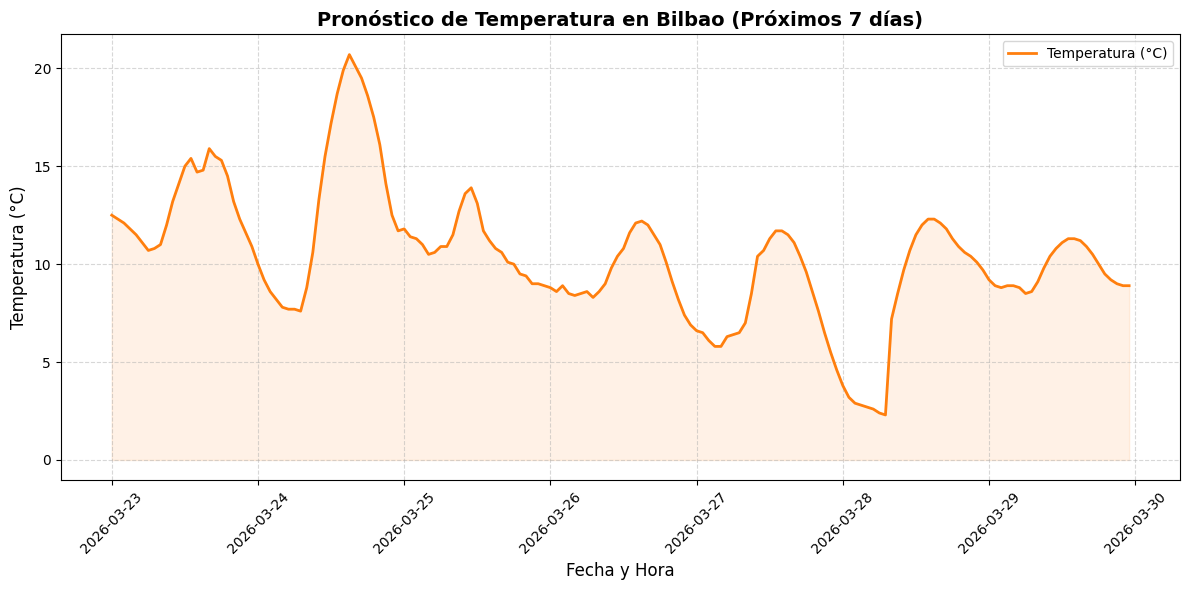

In [7]:
import matplotlib.pyplot as plt

# 1. Preparación de la gráfica
plt.figure(figsize=(12, 6))

# 2. Dibujar la línea de temperatura
plt.plot(df['Hora'], df['Temperatura'], color='#ff7f0e', linewidth=2, label='Temperatura (°C)')

# 3. Añadir sombreado para mejorar la estética
plt.fill_between(df['Hora'], df['Temperatura'], color='#ff7f0e', alpha=0.1)

# 4. Personalización de etiquetas y título
plt.title('Pronóstico de Temperatura en Bilbao (Próximos 7 días)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha y Hora', fontsize=12)
plt.ylabel('Temperatura (°C)', fontsize=12)

# 5. Ajustes finales para que se vea limpio
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45) # Rota las fechas para que no se amontonen
plt.legend()
plt.tight_layout()

# Mostrar la gráfica
plt.show()
